Дані завантажено успішно
Шлях до файлу: ..\data_raw\application_train.csv
Кількість рядків: 307511
Кількість ознак: 122
Кількість числових ознак: 104
Кількість категоріальних ознак: 16

Топ-20 числових ознак за кореляцією Пірсона з TARGET:
                         Ознака    Метод  Значення  Абсолютне значення
29                 EXT_SOURCE_3  Pearson -0.178919            0.178919
28                 EXT_SOURCE_2  Pearson -0.160472            0.160472
27                 EXT_SOURCE_1  Pearson -0.155317            0.155317
6                    DAYS_BIRTH  Pearson  0.078239            0.078239
19  REGION_RATING_CLIENT_W_CITY  Pearson  0.060893            0.060893
18         REGION_RATING_CLIENT  Pearson  0.058899            0.058899
77       DAYS_LAST_PHONE_CHANGE  Pearson  0.055218            0.055218
9               DAYS_ID_PUBLISH  Pearson  0.051457            0.051457
25       REG_CITY_NOT_WORK_CITY  Pearson  0.050994            0.050994
12               FLAG_EMP_PHONE  Pearson  0.045982

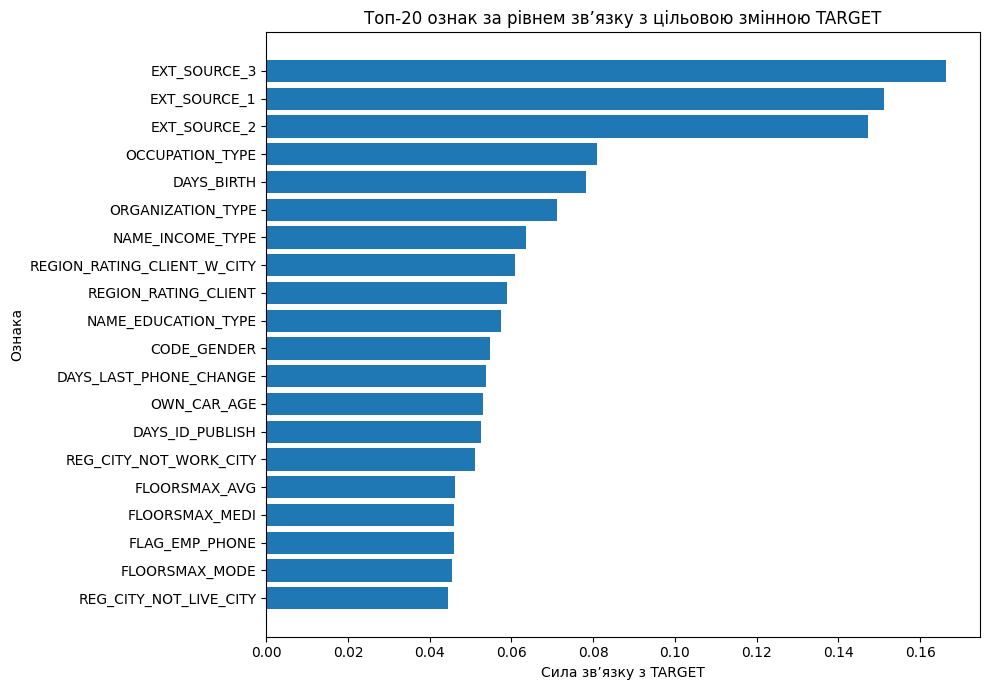


Топ-50 пар числових ознак із найбільшою взаємною кореляцією:
                          Ознака 1                      Ознака 2  \
704                  DAYS_EMPLOYED                FLAG_EMP_PHONE   
2869               YEARS_BUILD_AVG              YEARS_BUILD_MEDI   
4863      OBS_30_CNT_SOCIAL_CIRCLE      OBS_60_CNT_SOCIAL_CIRCLE   
3209                 FLOORSMIN_AVG                FLOORSMIN_MEDI   
3143                 FLOORSMAX_AVG                FLOORSMAX_MEDI   
3076                 ENTRANCES_AVG                ENTRANCES_MEDI   
3008                 ELEVATORS_AVG                ELEVATORS_MEDI   
2939                COMMONAREA_AVG               COMMONAREA_MEDI   
3401                LIVINGAREA_AVG               LIVINGAREA_MEDI   
2653                APARTMENTS_AVG               APARTMENTS_MEDI   
2726              BASEMENTAREA_AVG             BASEMENTAREA_MEDI   
3338          LIVINGAPARTMENTS_AVG         LIVINGAPARTMENTS_MEDI   
2798   YEARS_BEGINEXPLUATATION_AVG  YEARS_BEGINEXPLUAT

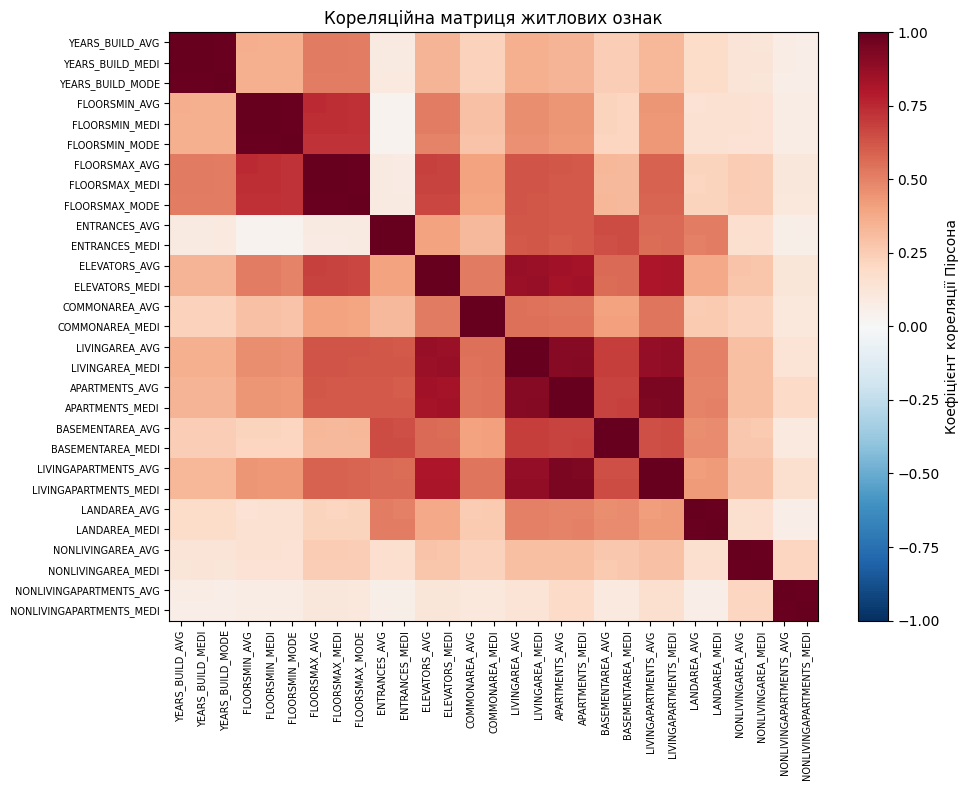

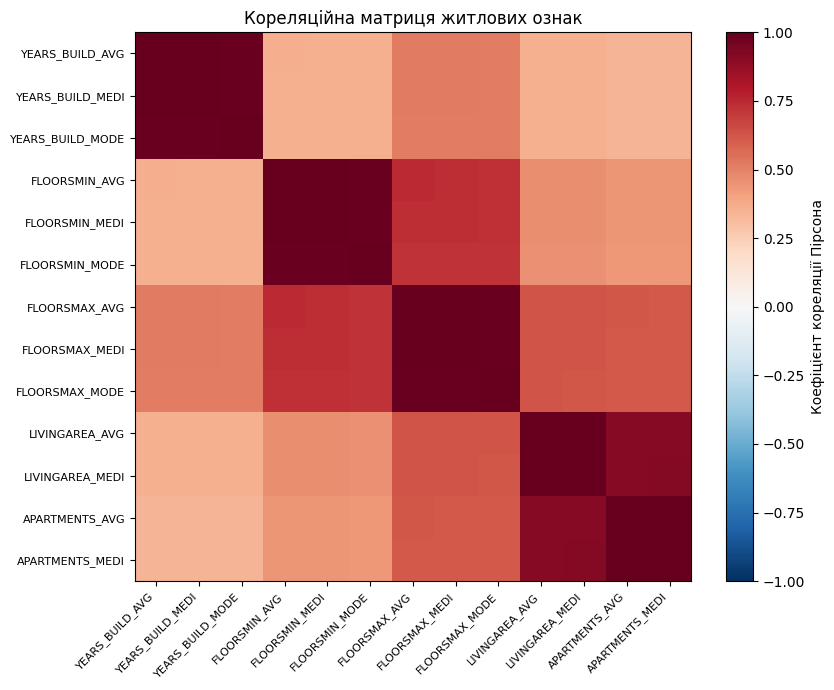


Формат для копіювання у Word:
Ознака	Тип ознаки	Метод	Значення
EXT_SOURCE_3	числова	Spearman	-0,16633
EXT_SOURCE_1	числова	Spearman	-0,151128
EXT_SOURCE_2	числова	Spearman	-0,147332
OCCUPATION_TYPE	категоріальна	V Крамера	0,08102
DAYS_BIRTH	числова	Spearman	0,078328
ORGANIZATION_TYPE	категоріальна	V Крамера	0,071048
NAME_INCOME_TYPE	категоріальна	V Крамера	0,063667
REGION_RATING_CLIENT_W_CITY	числова	Spearman	0,060936
REGION_RATING_CLIENT	числова	Spearman	0,058909
NAME_EDUCATION_TYPE	категоріальна	V Крамера	0,057458
CODE_GENDER	категоріальна	V Крамера	0,054661
DAYS_LAST_PHONE_CHANGE	числова	Spearman	0,053711
OWN_CAR_AGE	числова	Spearman	0,052932
DAYS_ID_PUBLISH	числова	Spearman	0,052535
REG_CITY_NOT_WORK_CITY	числова	Spearman	0,050994
FLOORSMAX_AVG	числова	Spearman	-0,046178
FLOORSMAX_MEDI	числова	Spearman	-0,046019
FLAG_EMP_PHONE	числова	Spearman	0,045982
FLOORSMAX_MODE	числова	Spearman	-0,045357
REG_CITY_NOT_LIVE_CITY	числова	Spearman	0,044395
FLAG_DOCUMENT_3	числова	Spearman	0,0443

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Назва цільової змінної, з якою порівнюються ознаки
target_col = "TARGET"

# Список можливих шляхів до основного файлу з даними
possible_paths = [
    Path("application_train.csv"),
    Path("data_raw/application_train.csv"),
    Path("data/data_raw/application_train.csv"),
    Path("../data_raw/application_train.csv"),
    Path("../data/data_raw/application_train.csv"),
    Path("../../data/data_raw/application_train.csv")
]

data_path = None

# Цикл перевіряє наявність файлу application_train.csv у вказаних директоріях
for path in possible_paths:
    if path.exists():
        data_path = path
        break

# Якщо файл не знайдено за стандартними шляхами, виконується автоматичний пошук у поточній папці
if data_path is None:
    found_files = list(Path.cwd().rglob("application_train.csv"))

    if len(found_files) > 0:
        data_path = found_files[0]
    else:
        raise FileNotFoundError("Файл application_train.csv не знайдено.")

# Зчитування набору даних з CSV-файлу
df = pd.read_csv(data_path)

# Виведення основної інформації про завантажений набір даних
print("Дані завантажено успішно")
print("Шлях до файлу:", data_path)
print("Кількість рядків:", df.shape[0])
print("Кількість ознак:", df.shape[1])

# Перевірка наявності цільової змінної у наборі даних
if target_col not in df.columns:
    raise ValueError("У наборі даних немає змінної TARGET.")

# Створення папки для збереження таблиць з результатами аналізу
tables_dir = Path("outputs/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

# Створення папки для збереження графіків
figures_dir = Path("outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# Формування списку числових ознак для кореляційного аналізу
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Видалення службових змінних, які не використовуються як звичайні фактори
for col in ["SK_ID_CURR", target_col]:
    if col in numeric_cols:
        numeric_cols.remove(col)

# Формування списку категоріальних ознак
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Видалення цільової змінної зі списку категоріальних ознак, якщо вона там є
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

# Виведення кількості ознак, які будуть використані в аналізі
print("Кількість числових ознак:", len(numeric_cols))
print("Кількість категоріальних ознак:", len(categorical_cols))


# Функція обчислює кореляцію Пірсона між числовими ознаками та цільовою змінною
def calculate_pearson_correlation(data, features, target):
    results = []

    # Цикл проходить по всіх числових ознаках
    for feature in features:
        temp = data[[feature, target]].dropna()

        # Ознаки з одним унікальним значенням не використовуються для кореляції
        if temp[feature].nunique() > 1:
            corr_value = temp[feature].corr(temp[target], method="pearson")

            results.append({
                "Ознака": feature,
                "Метод": "Pearson",
                "Значення": corr_value,
                "Абсолютне значення": abs(corr_value)
            })

    # Результати перетворюються у таблицю
    result_table = pd.DataFrame(results)

    # Таблиця сортується за абсолютним значенням коефіцієнта
    result_table = result_table.sort_values(
        by="Абсолютне значення",
        ascending=False
    )

    # Значення округлюються для зручного подання у роботі
    result_table["Значення"] = result_table["Значення"].round(6)
    result_table["Абсолютне значення"] = result_table["Абсолютне значення"].round(6)

    return result_table


# Функція обчислює кореляцію Спірмена між числовими ознаками та цільовою змінною
def calculate_spearman_correlation(data, features, target):
    results = []

    # Цикл проходить по всіх числових ознаках
    for feature in features:
        temp = data[[feature, target]].dropna()

        # Перевірка потрібна, щоб не рахувати кореляцію для сталої ознаки
        if temp[feature].nunique() > 1:
            corr_value = temp[feature].corr(temp[target], method="spearman")

            results.append({
                "Ознака": feature,
                "Метод": "Spearman",
                "Значення": corr_value,
                "Абсолютне значення": abs(corr_value)
            })

    # Результати перетворюються у таблицю
    result_table = pd.DataFrame(results)

    # Сортування виконується за силою зв’язку з TARGET
    result_table = result_table.sort_values(
        by="Абсолютне значення",
        ascending=False
    )

    # Округлення значень використовується для подальшого оформлення таблиць
    result_table["Значення"] = result_table["Значення"].round(6)
    result_table["Абсолютне значення"] = result_table["Абсолютне значення"].round(6)

    return result_table


# Функція обчислює V Крамера для оцінки зв’язку між категоріальною ознакою та TARGET
def cramers_v(x, y):
    # Таблиця спряженості показує розподіл категорій ознаки відносно TARGET
    confusion_matrix = pd.crosstab(x, y)

    # Якщо у таблиці недостатньо категорій, показник не розраховується
    if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return np.nan

    observed = confusion_matrix.values
    n = observed.sum()

    # Перевірка захищає від ділення на нуль
    if n == 0:
        return np.nan

    # Обчислення сум за рядками та стовпцями таблиці спряженості
    row_sums = observed.sum(axis=1).reshape(-1, 1)
    col_sums = observed.sum(axis=0).reshape(1, -1)

    # Обчислення очікуваних частот для критерію хі-квадрат
    expected = row_sums @ col_sums / n

    # Нульові очікувані значення замінюються, щоб уникнути помилки ділення
    expected = np.where(expected == 0, np.nan, expected)

    # Обчислення статистики хі-квадрат
    chi2 = np.nansum((observed - expected) ** 2 / expected)

    r, k = observed.shape
    phi2 = chi2 / n

    # Корекція показника зменшує зміщення для малих таблиць
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(kcorr - 1, rcorr - 1)

    # Якщо знаменник некоректний, результат не визначається
    if denominator <= 0:
        return np.nan

    return np.sqrt(phi2corr / denominator)


# Функція обчислює V Крамера для всіх категоріальних ознак
def calculate_cramers_v_table(data, features, target):
    results = []

    # Цикл проходить по всіх категоріальних ознаках
    for feature in features:
        temp = data[[feature, target]].dropna()

        # Ознаки з одним значенням не несуть інформації для аналізу зв’язку
        if temp[feature].nunique() > 1:
            value = cramers_v(temp[feature], temp[target])

            results.append({
                "Ознака": feature,
                "Метод": "V Крамера",
                "Значення": value,
                "Абсолютне значення": abs(value)
            })

    # Результати перетворюються у таблицю
    result_table = pd.DataFrame(results)

    # Пропущені значення видаляються з підсумкової таблиці
    result_table = result_table.dropna()

    # Категоріальні ознаки сортуються за силою зв’язку з TARGET
    result_table = result_table.sort_values(
        by="Абсолютне значення",
        ascending=False
    )

    # Значення округлюються до шести знаків
    result_table["Значення"] = result_table["Значення"].round(6)
    result_table["Абсолютне значення"] = result_table["Абсолютне значення"].round(6)

    return result_table


# Обчислення кореляції Пірсона для числових ознак
pearson_table = calculate_pearson_correlation(df, numeric_cols, target_col)

print("\nТоп-20 числових ознак за кореляцією Пірсона з TARGET:")
print(pearson_table.head(20))

# Збереження результатів кореляції Пірсона у CSV-файл
pearson_table.to_csv(
    tables_dir / "pearson_correlation_with_target.csv",
    index=False,
    encoding="utf-8-sig"
)


# Обчислення кореляції Спірмена для числових ознак
spearman_table = calculate_spearman_correlation(df, numeric_cols, target_col)

print("\nТоп-20 числових ознак за кореляцією Спірмена з TARGET:")
print(spearman_table.head(20))

# Збереження результатів кореляції Спірмена у CSV-файл
spearman_table.to_csv(
    tables_dir / "spearman_correlation_with_target.csv",
    index=False,
    encoding="utf-8-sig"
)


# Обчислення V Крамера для категоріальних ознак
cramer_table = calculate_cramers_v_table(df, categorical_cols, target_col)

print("\nТоп категоріальних ознак за V Крамера:")
print(cramer_table.head(20))

# Збереження результатів V Крамера у CSV-файл
cramer_table.to_csv(
    tables_dir / "cramers_v_with_target.csv",
    index=False,
    encoding="utf-8-sig"
)


# Об’єднання результатів для числових і категоріальних ознак
association_table = pd.concat([
    spearman_table.assign(**{"Тип ознаки": "числова"}),
    cramer_table.assign(**{"Тип ознаки": "категоріальна"})
], ignore_index=True)

# Зведена таблиця сортується за найбільшим зв’язком із TARGET
association_table = association_table.sort_values(
    by="Абсолютне значення",
    ascending=False
)

print("\nЗведена таблиця ознак із найбільшим зв’язком із TARGET:")
print(association_table.head(25))

# Збереження зведеної таблиці зв’язку ознак із цільовою змінною
association_table.to_csv(
    tables_dir / "association_with_target.csv",
    index=False,
    encoding="utf-8-sig"
)


# Вибір 20 ознак із найбільшим зв’язком з TARGET
top20 = association_table.head(20).sort_values("Абсолютне значення")

# Побудова стовпчикової діаграми для найбільш пов’язаних ознак
plt.figure(figsize=(10, 7))
plt.barh(top20["Ознака"], top20["Абсолютне значення"])
plt.xlabel("Сила зв’язку з TARGET")
plt.ylabel("Ознака")
plt.title("Топ-20 ознак за рівнем зв’язку з цільовою змінною TARGET")
plt.tight_layout()
plt.savefig(figures_dir / "top20_features_association_with_target.png", dpi=300)
plt.show()


# Формування таблиці тільки з числовими ознаками
numeric_df = df[numeric_cols].copy()

# Обчислення кореляційної матриці між числовими ознаками
corr_matrix = numeric_df.corr(method="pearson")

# Збереження повної кореляційної матриці у файл
corr_matrix.to_csv(
    tables_dir / "numeric_features_correlation_matrix.csv",
    encoding="utf-8-sig"
)


# Формування списку пар числових ознак з високою взаємною кореляцією
corr_pairs = []

features = corr_matrix.columns

# Подвійний цикл проходить по всіх парах числових ознак без повторів
for i in range(len(features)):
    for j in range(i + 1, len(features)):
        feature_1 = features[i]
        feature_2 = features[j]
        corr_value = corr_matrix.loc[feature_1, feature_2]

        # До таблиці додаються тільки коректні значення кореляції
        if pd.notna(corr_value):
            corr_pairs.append({
                "Ознака 1": feature_1,
                "Ознака 2": feature_2,
                "Коефіцієнт кореляції": corr_value,
                "Абсолютне значення": abs(corr_value)
            })

# Список пар перетворюється у таблицю
top_corr_pairs = pd.DataFrame(corr_pairs)

# Пари ознак сортуються за абсолютним значенням кореляції
top_corr_pairs = top_corr_pairs.sort_values(
    by="Абсолютне значення",
    ascending=False
)

# Значення округлюються для подальшого використання в роботі
top_corr_pairs["Коефіцієнт кореляції"] = top_corr_pairs["Коефіцієнт кореляції"].round(6)
top_corr_pairs["Абсолютне значення"] = top_corr_pairs["Абсолютне значення"].round(6)

print("\nТоп-50 пар числових ознак із найбільшою взаємною кореляцією:")
print(top_corr_pairs.head(50))

# Збереження таблиці найбільш корельованих пар ознак
top_corr_pairs.head(50).to_csv(
    tables_dir / "top50_correlated_feature_pairs.csv",
    index=False,
    encoding="utf-8-sig"
)


# Список житлових ознак для окремої кореляційної матриці
housing_features = [
    "YEARS_BUILD_AVG",
    "YEARS_BUILD_MEDI",
    "YEARS_BUILD_MODE",
    "FLOORSMIN_AVG",
    "FLOORSMIN_MEDI",
    "FLOORSMIN_MODE",
    "FLOORSMAX_AVG",
    "FLOORSMAX_MEDI",
    "FLOORSMAX_MODE",
    "ENTRANCES_AVG",
    "ENTRANCES_MEDI",
    "ELEVATORS_AVG",
    "ELEVATORS_MEDI",
    "COMMONAREA_AVG",
    "COMMONAREA_MEDI",
    "LIVINGAREA_AVG",
    "LIVINGAREA_MEDI",
    "APARTMENTS_AVG",
    "APARTMENTS_MEDI",
    "BASEMENTAREA_AVG",
    "BASEMENTAREA_MEDI",
    "LIVINGAPARTMENTS_AVG",
    "LIVINGAPARTMENTS_MEDI",
    "LANDAREA_AVG",
    "LANDAREA_MEDI",
    "NONLIVINGAREA_AVG",
    "NONLIVINGAREA_MEDI",
    "NONLIVINGAPARTMENTS_AVG",
    "NONLIVINGAPARTMENTS_MEDI"
]

# Відбір тільки тих житлових ознак, які є у завантаженому наборі даних
housing_features = [col for col in housing_features if col in df.columns]

# Обчислення кореляційної матриці для житлових характеристик
housing_corr_matrix = df[housing_features].corr(method="pearson")

print("\nКількість житлових ознак для матриці:", len(housing_features))

# Побудова теплової карти кореляцій для житлових ознак
plt.figure(figsize=(10, 8))

img = plt.imshow(
    housing_corr_matrix,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(img, label="Коефіцієнт кореляції Пірсона")
plt.xticks(
    ticks=np.arange(len(housing_features)),
    labels=housing_features,
    rotation=90,
    fontsize=7
)
plt.yticks(
    ticks=np.arange(len(housing_features)),
    labels=housing_features,
    fontsize=7
)
plt.title("Кореляційна матриця житлових ознак")
plt.tight_layout()
plt.savefig(figures_dir / "housing_features_correlation_matrix.png", dpi=300)
plt.show()


# Скорочений список житлових ознак для компактної матриці
compact_housing_features = [
    "YEARS_BUILD_AVG",
    "YEARS_BUILD_MEDI",
    "YEARS_BUILD_MODE",
    "FLOORSMIN_AVG",
    "FLOORSMIN_MEDI",
    "FLOORSMIN_MODE",
    "FLOORSMAX_AVG",
    "FLOORSMAX_MEDI",
    "FLOORSMAX_MODE",
    "LIVINGAREA_AVG",
    "LIVINGAREA_MEDI",
    "APARTMENTS_AVG",
    "APARTMENTS_MEDI"
]

# Відбір тільки наявних у датасеті ознак
compact_housing_features = [
    col for col in compact_housing_features
    if col in df.columns
]

# Обчислення компактної кореляційної матриці
compact_corr_matrix = df[compact_housing_features].corr(method="pearson")

# Побудова компактної теплової карти для вставки у диплом
plt.figure(figsize=(8.5, 7))

img = plt.imshow(
    compact_corr_matrix,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(img, label="Коефіцієнт кореляції Пірсона")
plt.xticks(
    ticks=np.arange(len(compact_housing_features)),
    labels=compact_housing_features,
    rotation=45,
    ha="right",
    fontsize=8
)
plt.yticks(
    ticks=np.arange(len(compact_housing_features)),
    labels=compact_housing_features,
    fontsize=8
)
plt.title("Кореляційна матриця житлових ознак")
plt.tight_layout()
plt.savefig(figures_dir / "compact_housing_features_correlation_matrix.png", dpi=300)
plt.show()


print("\nФормат для копіювання у Word:")
print("Ознака\tТип ознаки\tМетод\tЗначення")

# Цикл формує текстові рядки для таблиці з найважливішими ознаками
for _, row in association_table.head(25).iterrows():
    value = str(row["Значення"]).replace(".", ",")
    print(f"{row['Ознака']}\t{row['Тип ознаки']}\t{row['Метод']}\t{value}")

print("\nКореляційний аналіз завершено.")